# Import Libraries

In [39]:
# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import joblib

In [40]:
#Load Dataset
df = pd.read_csv("diabetics.csv")

In [41]:
df.head()

,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
0,P0529,2,120,82,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5,0
1,P0283,8,121,107,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2,1
2,P0844,12,177,100,53.0,376.0,42.8,2.195,37.0,218,141.3,85,46.9,NaN,1
3,P0121,2,115,0,NaN,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3,0
4,P0001,2,129,80,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8,0


In [42]:
df.tail()

,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
1010,P0768,7,NaN,57,32.0,40.0,35.4,1.076,39.0,226,143.0,75,NaN,3.0,0
1011,P0746,2,131,0,12.0,196.0,26.5,0.724,34.0,155,139.0,92,51.3,7.6,0
1012,P0071,4,144,69,33.0,305.0,30.7,0.988,27.0,150,140.7,94,15.1,3.6,1
1013,P0608,0,79,59,27.0,29.0,27.9,0.370,200.0,235,135.6,61,56.9,9.0,0
1014,P0990,5,139#,62,23.0,174.0,22.0,0.915,50.0,190,137.0,98,NaN,3.5,0


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 1015 non-null   str    
 1   Pregnancies               1015 non-null   int64  
 2   Glucose                   935 non-null    str    
 3   BloodPressure             1015 non-null   int64  
 4   SkinThickness             935 non-null    float64
 5   Insulin                   937 non-null    float64
 6   BMI                       1015 non-null   float64
 7   DiabetesPedigreeFunction  1015 non-null   float64
 8   Age                       1015 non-null   float64
 9   Cholesterol               1015 non-null   int64  
 10  SodiumLevel               1015 non-null   float64
 11  HeartRate                 1015 non-null   int64  
 12  VitaminD                  934 non-null    float64
 13  ExerciseHrsPerWeek        933 non-null    float64
 14  Outcome            

In [44]:
print("Rows and Columns :", df.shape)

Rows and Columns : (1015, 15)


In [45]:
print(df.columns)

Index(['PatientID', 'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
       'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Cholesterol',
       'SodiumLevel', 'HeartRate', 'VitaminD', 'ExerciseHrsPerWeek',
       'Outcome'],
      dtype='str')


In [46]:
df.dtypes

PatientID                       str
Pregnancies                   int64
Glucose                         str
BloodPressure                 int64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Cholesterol                   int64
SodiumLevel                 float64
HeartRate                     int64
VitaminD                    float64
ExerciseHrsPerWeek          float64
Outcome                         str
dtype: object

In [47]:
df.describe()

,Pregnancies,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek
count,1015.000000,1015.000000,935.000000,937.000000,1015.000000,1015.000000,1015.000000,1015.000000,1015.000000,1015.000000,934.000000,933.000000
mean,3.953695,77.821675,28.067380,247.248666,32.257143,0.886528,41.093005,200.347783,139.683547,78.359606,35.294540,5.025938
std,3.021753,25.586700,12.381894,965.699749,11.635791,0.565512,19.757258,29.370453,2.948790,19.932078,14.188464,2.924371
min,-7.000000,0.000000,-43.000000,-10.000000,-3.000000,0.080000,-1.000000,150.000000,135.000000,-99.000000,10.100000,0.000000
25%,2.000000,65.000000,20.000000,85.000000,25.450000,0.441000,29.000000,176.000000,137.100000,69.000000,23.225000,2.500000
50%,3.000000,76.000000,28.000000,136.000000,31.100000,0.793000,38.000000,202.000000,139.400000,80.000000,35.300000,5.100000
75%,6.000000,87.000000,37.000000,196.000000,36.850000,1.146000,51.000000,226.000000,142.200000,90.000000,47.850000,7.700000
max,12.000000,300.000000,54.000000,9999.000000,120.500000,2.413000,200.000000,250.000000,145.000000,100.000000,59.800000,10.000000


In [48]:
df.isnull().sum()

PatientID                    0
Pregnancies                  0
Glucose                     80
BloodPressure                0
SkinThickness               80
Insulin                     78
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Cholesterol                  0
SodiumLevel                  0
HeartRate                    0
VitaminD                    81
ExerciseHrsPerWeek          82
Outcome                      0
dtype: int64

In [49]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 15


In [50]:
print(df["Outcome"].value_counts())

Outcome
0        644
1        351
Yes        5
0.0        5
No         5
1.0        2
FALSE      2
TRUE       1
Name: count, dtype: int64


In [51]:
columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in columns:
    df[col] = df[col].replace(0, np.nan)

In [52]:
df.fillna(df.median(numeric_only=True), inplace=True)

,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
0,P0529,2,120,82.0,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5,0
1,P0283,8,121,107.0,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2,1
2,P0844,12,177,100.0,53.0,376.0,42.8,2.195,37.0,218,141.3,85,46.9,5.1,1
3,P0121,2,115,76.0,28.0,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3,0
4,P0001,2,129,80.0,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,P0768,7,NaN,57.0,32.0,40.0,35.4,1.076,39.0,226,143.0,75,35.3,3.0,0
1011,P0746,2,131,76.0,12.0,196.0,26.5,0.724,34.0,155,139.0,92,51.3,7.6,0
1012,P0071,4,144,69.0,33.0,305.0,30.7,0.988,27.0,150,140.7,94,15.1,3.6,1
1013,P0608,0,79,59.0,27.0,29.0,27.9,0.370,200.0,235,135.6,61,56.9,9.0,0


In [53]:
df.drop_duplicates(inplace=True)

In [54]:
print(df.shape)

(1000, 15)


# Data Preprocessing

In [55]:
# Separate Features and Target

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1000, 14)
Target Shape : (1000,)


In [56]:
X.head()

,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek
0,P0529,2,120,82.0,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5
1,P0283,8,121,107.0,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2
2,P0844,12,177,100.0,53.0,376.0,42.8,2.195,37.0,218,141.3,85,46.9,5.1
3,P0121,2,115,76.0,28.0,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3
4,P0001,2,129,80.0,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8


In [57]:
y.head()

0    0
1    1
2    1
3    0
4    0
Name: Outcome, dtype: str

In [58]:
# Remove PatientID

if "PatientID" in X.columns:
    X.drop("PatientID", axis=1, inplace=True)
print(X.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Cholesterol', 'SodiumLevel',
       'HeartRate', 'VitaminD', 'ExerciseHrsPerWeek'],
      dtype='str')


In [59]:
X.dtypes

Pregnancies                   int64
Glucose                         str
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Cholesterol                   int64
SodiumLevel                 float64
HeartRate                     int64
VitaminD                    float64
ExerciseHrsPerWeek          float64
dtype: object

In [64]:
for col in X.columns:
    if X[col].dtype == "object":
        print(f"\nColumn: {col}")
        print(X[col].unique())

In [65]:
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

In [66]:
X.fillna(X.median(numeric_only=True), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek
0,2,120.0,82.0,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5
1,8,121.0,107.0,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2
2,12,177.0,100.0,53.0,376.0,42.8,2.195,37.0,218,141.3,85,46.9,5.1
3,2,115.0,76.0,28.0,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3
4,2,129.0,80.0,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1009,0,136.0,81.0,20.0,72.0,120.5,0.435,52.0,187,142.2,83,22.4,9.1
1010,7,122.5,57.0,32.0,40.0,35.4,1.076,39.0,226,143.0,75,35.3,3.0
1011,2,131.0,76.0,12.0,196.0,26.5,0.724,34.0,155,139.0,92,51.3,7.6
1012,4,144.0,69.0,33.0,305.0,30.7,0.988,27.0,150,140.7,94,15.1,3.6


In [69]:
# Train-Test Split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25)

print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape :", X_test.shape)
print("Training Label Shape :", y_train.shape)
print("Testing Label Shape :", y_test.shape)

Training Feature Shape : (750, 13)
Testing Feature Shape : (250, 13)
Training Label Shape : (750,)
Testing Label Shape : (250,)


In [70]:
# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
print(y.value_counts())

Outcome
0        637
1        343
Yes        5
0.0        5
No         5
1.0        2
FALSE      2
TRUE       1
Name: count, dtype: int64


## 1. Logistic Regression

In [73]:
# Build Logistic Regression Model and Prediction

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
logistic_model.fit(X_train_scaled, y_train)

y_pred_lr = logistic_model.predict(X_test_scaled)
print(y_pred_lr[:10])

['1' '1' '1' '1' '1' '1' '0' '0' '1' '1']


In [74]:
# Accuracy Score, Precision, Recall and F1 Score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy :", accuracy_lr)
print("Accuracy Percentage :", accuracy_lr * 100)

precision_lr = precision_score(y_test, y_pred_lr, average = 'weighted')

recall_lr = recall_score(y_test, y_pred_lr, average = 'weighted')

f1_lr = f1_score(y_test, y_pred_lr, average = 'weighted')

print("Precision :", precision_lr)
print("Recall    :", recall_lr)
print("F1 Score  :", f1_lr)

Accuracy : 0.932
Accuracy Percentage : 93.2
Precision : 0.9208024146737869
Recall    : 0.932
F1 Score  : 0.9259392122958694


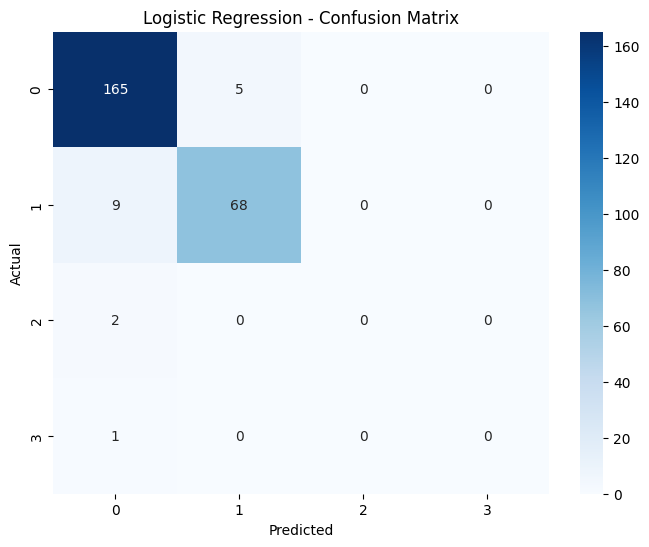

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       170
           1       0.93      0.88      0.91        77
         1.0       0.00      0.00      0.00         2
       FALSE       0.00      0.00      0.00         1

    accuracy                           0.93       250
   macro avg       0.47      0.46      0.46       250
weighted avg       0.92      0.93      0.93       250



,Actual,Predicted
215,1,1
209,1,1
322,1,1
945,0,1
691,1,1
452,1,1
319,0,0
408,0,0
481,1,1
958,1,1


In [76]:
# Confusion Matrix and Classification Report

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8,6))
sns.heatmap(cm_lr, annot = True, fmt = 'd', cmap = 'Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report")
print(classification_report(y_test, y_pred_lr))

# Actual vs Predicted
comparison_lr = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lr
})
comparison_lr.head(10)

In [77]:
# Store Results

results = []
results.append({
    "Model":"Logistic Regression",
    "Accuracy":accuracy_lr,
    "Precision":precision_lr,
    "Recall":recall_lr,
    "F1 Score":f1_lr
})
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.932,0.920802,0.932,0.925939


## 2. Decision Tree

In [78]:
# Build Decision Tree Classifier and Prediction

decision_tree = DecisionTreeClassifier(
    random_state=42
)
decision_tree.fit(X_train_scaled, y_train)

y_pred_dt = decision_tree.predict(X_test_scaled)
print(y_pred_dt[:10])

['1' '1' '1' '0' '1' '1' '0' '0' '1' '1']


In [79]:
# Accuracy Score, Precision, Recall and F1 Score

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Accuracy :", accuracy_dt)
print("Accuracy Percentage :", accuracy_dt * 100)

precision_dt = precision_score(y_test, y_pred_dt, average = 'weighted')

recall_dt = recall_score(y_test, y_pred_dt, average = 'weighted')

f1_dt = f1_score(y_test, y_pred_dt, average = 'weighted')

print("Precision :", precision_dt)
print("Recall    :", recall_dt)
print("F1 Score  :", f1_dt)

Accuracy : 0.952
Accuracy Percentage : 95.19999999999999
Precision : 0.9598095238095238
Recall    : 0.952
F1 Score  : 0.9558816568047337


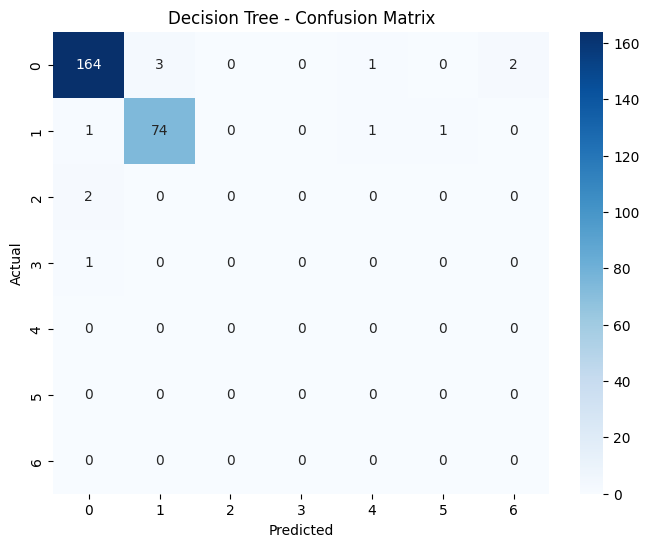

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       170
           1       0.96      0.96      0.96        77
         1.0       0.00      0.00      0.00         2
       FALSE       0.00      0.00      0.00         1
          No       0.00      0.00      0.00         0
        TRUE       0.00      0.00      0.00         0
         Yes       0.00      0.00      0.00         0

    accuracy                           0.95       250
   macro avg       0.28      0.28      0.28       250
weighted avg       0.96      0.95      0.96       250



,Actual,Predicted
215,1,1
209,1,1
322,1,1
945,0,0
691,1,1
452,1,1
319,0,0
408,0,0
481,1,1
958,1,1


In [80]:
# Confusion Matrix and Classification Report

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot = True, fmt = 'd', cmap = 'Blues')
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report")
print(classification_report(y_test, y_pred_dt))

# Actual vs Predicted
comparison_dt = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_dt
})
comparison_dt.head(10)

In [81]:
# Store Results

results.append({
    "Model":"Decision Tree",
    "Accuracy":accuracy_dt,
    "Precision":precision_dt,
    "Recall":recall_dt,
    "F1 Score":f1_dt
})
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.932,0.920802,0.932,0.925939
1,Decision Tree,0.952,0.959810,0.952,0.955882


## 3. Random Forest

In [82]:
# Build Random Forest Classifier and Prediction

from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(n_estimators = 100, random_state = 42)
random_forest.fit(X_train_scaled, y_train)

y_pred_rf = random_forest.predict(X_test_scaled)
print(y_pred_rf[:10])

['1' '1' '1' '0' '1' '1' '0' '0' '1' '1']


In [83]:
# Accuracy Score, Precision, Recall and F1 Score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy :", accuracy_rf)
print("Accuracy Percentage :", accuracy_rf * 100)

precision_rf = precision_score(y_test, y_pred_rf, average = 'weighted')

recall_rf = recall_score(y_test, y_pred_rf, average = 'weighted')

f1_rf = f1_score(y_test, y_pred_rf, average = 'weighted')

print("Precision :", precision_rf)
print("Recall    :", recall_rf)
print("F1 Score  :", f1_rf)

Accuracy : 0.984
Accuracy Percentage : 98.4
Precision : 0.9723678160919541
Recall    : 0.984
F1 Score  : 0.978079951360389


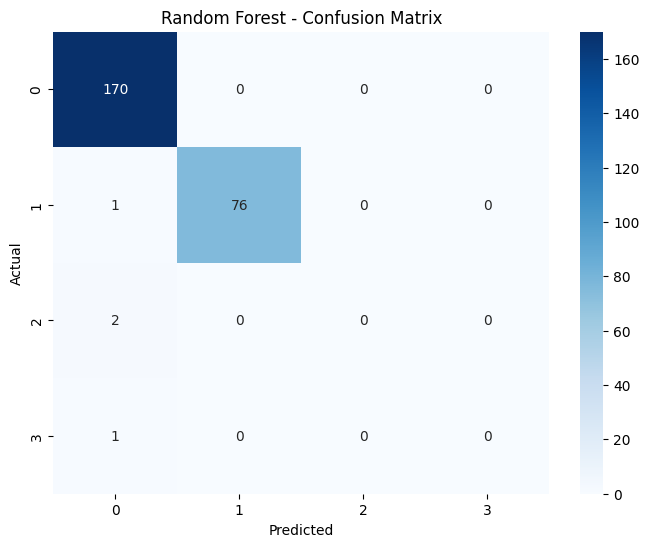

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       170
           1       1.00      0.99      0.99        77
         1.0       0.00      0.00      0.00         2
       FALSE       0.00      0.00      0.00         1

    accuracy                           0.98       250
   macro avg       0.49      0.50      0.50       250
weighted avg       0.97      0.98      0.98       250



,Actual,Predicted
215,1,1
209,1,1
322,1,1
945,0,0
691,1,1
452,1,1
319,0,0
408,0,0
481,1,1
958,1,1


In [84]:
# Confusion Matrix and Classification Report

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot = True, fmt = 'd', cmap = 'Blues')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report")
print(classification_report(y_test, y_pred_rf))

# Actual vs Predicted
comparison_rf = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})
comparison_rf.head(10)

In [85]:
# Store Results

results.append({
    "Model":"Random Forest",
    "Accuracy":accuracy_rf,
    "Precision":precision_rf,
    "Recall":recall_rf,
    "F1 Score":f1_rf
})
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.932,0.920802,0.932,0.925939
1,Decision Tree,0.952,0.959810,0.952,0.955882
2,Random Forest,0.984,0.972368,0.984,0.978080


In [87]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance

,Feature,Importance
1,Glucose,0.251428
6,DiabetesPedigreeFunction,0.203556
5,BMI,0.156322
4,Insulin,0.135802
2,BloodPressure,0.093914
3,SkinThickness,0.053617
0,Pregnancies,0.034507
7,Age,0.015747
12,ExerciseHrsPerWeek,0.014506
8,Cholesterol,0.011005


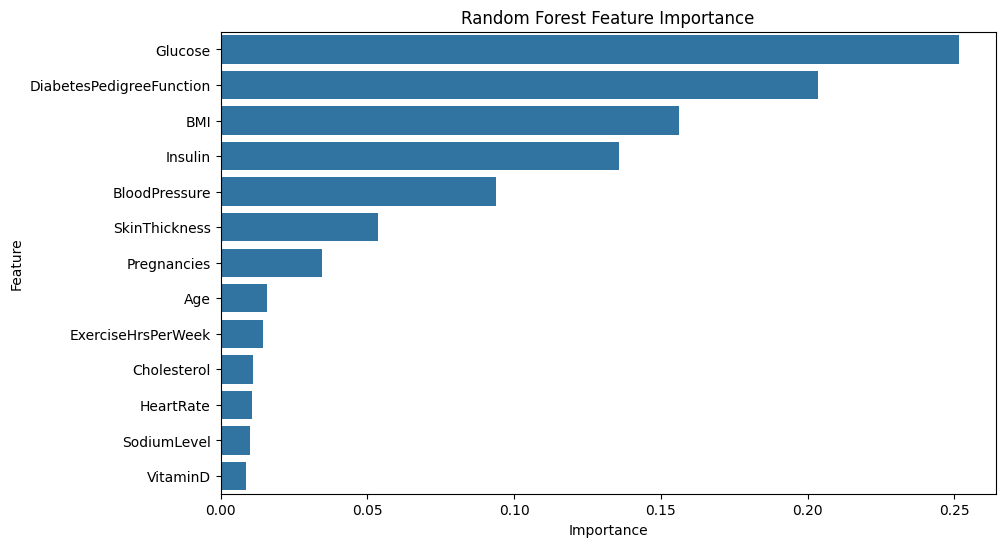

In [88]:
# Feature Importance Graph

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Random Forest Feature Importance")
plt.show()

## 4. K-Nearest Neighbors

In [89]:
# Build K-Nearest Neighbors (KNN) Classifier and Prediction

knn = KNeighborsClassifier(
    n_neighbors=5
)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
print(y_pred_knn[:10])

['1' '1' '1' '0' '0' '1' '0' '0' '0' '0']


In [90]:
# Accuracy Score, Precision, Recall and F1 Score

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy :", accuracy_knn)
print("Accuracy Percentage :", accuracy_knn * 100)

precision_knn = precision_score(y_test, y_pred_knn, average = 'weighted')

recall_knn = recall_score(y_test, y_pred_knn, average = 'weighted')

f1_knn = f1_score(y_test, y_pred_knn, average = 'weighted')

print("Precision :", precision_knn)
print("Recall    :", recall_knn)
print("F1 Score  :", f1_knn)

Accuracy : 0.92
Accuracy Percentage : 92.0
Precision : 0.9164210526315789
Recall    : 0.92
F1 Score  : 0.9120032441200324


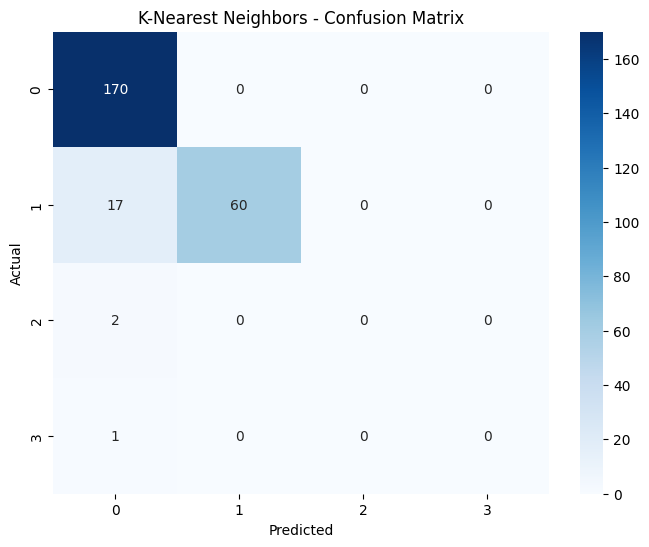

Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       170
           1       1.00      0.78      0.88        77
         1.0       0.00      0.00      0.00         2
       FALSE       0.00      0.00      0.00         1

    accuracy                           0.92       250
   macro avg       0.47      0.44      0.46       250
weighted avg       0.92      0.92      0.91       250



,Actual,Predicted
215,1,1
209,1,1
322,1,1
945,0,0
691,1,0
452,1,1
319,0,0
408,0,0
481,1,0
958,1,0


In [91]:
# Confusion Matrix and Classification Report

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot = True, fmt = 'd', cmap = 'Blues')
plt.title("K-Nearest Neighbors - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report")
print(classification_report(y_test, y_pred_knn))

# Actual vs Predicted
comparison_knn = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_knn
})
comparison_knn.head(10)

In [92]:
# Store Results

results.append({
    "Model":"KNN",
    "Accuracy":accuracy_knn,
    "Precision":precision_knn,
    "Recall":recall_knn,
    "F1 Score":f1_knn
})
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.932,0.920802,0.932,0.925939
1,Decision Tree,0.952,0.959810,0.952,0.955882
2,Random Forest,0.984,0.972368,0.984,0.978080
3,KNN,0.920,0.916421,0.920,0.912003


## 5. Support Vector Machine

In [93]:
# Build Support Vector Machine (SVM) Classifier and Prediction

svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
print(y_pred_svm[:10])

['1' '1' '1' '0' '1' '1' '0' '0' '1' '1']


In [94]:
# Accuracy Score, Precision, Recall and F1 Score

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy :", accuracy_svm)
print("Accuracy Percentage :", accuracy_svm * 100)

precision_svm = precision_score(y_test, y_pred_svm, average = 'weighted')

recall_svm = recall_score(y_test, y_pred_svm, average = 'weighted')

f1_svm = f1_score(y_test, y_pred_svm, average = 'weighted')

print("Precision :", precision_svm)
print("Recall    :", recall_svm)
print("F1 Score  :", f1_svm)

Accuracy : 0.96
Accuracy Percentage : 96.0
Precision : 0.9493401997503121
Recall    : 0.96
F1 Score  : 0.9539899714572244


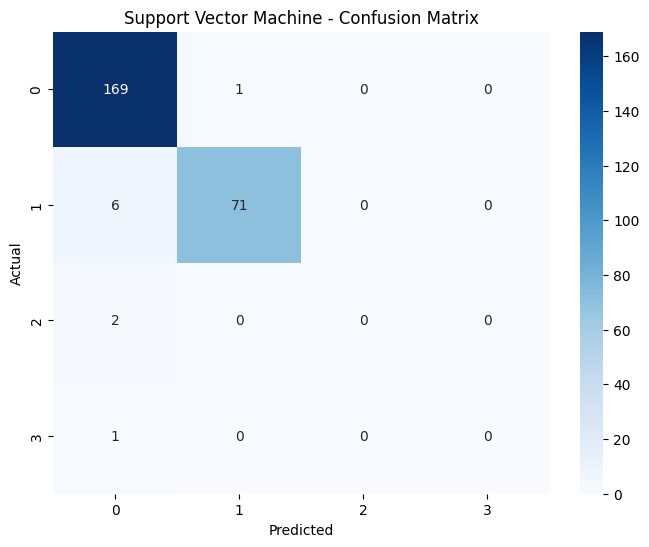

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       170
           1       0.99      0.92      0.95        77
         1.0       0.00      0.00      0.00         2
       FALSE       0.00      0.00      0.00         1

    accuracy                           0.96       250
   macro avg       0.48      0.48      0.48       250
weighted avg       0.95      0.96      0.95       250



,Actual,Predicted
215,1,1
209,1,1
322,1,1
945,0,0
691,1,1
452,1,1
319,0,0
408,0,0
481,1,1
958,1,1


In [95]:
# Confusion Matrix and Classification Report

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title("Support Vector Machine - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report")
print(classification_report(y_test, y_pred_svm))

# Actual vs Predicted
comparison_svm = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_svm
})
comparison_svm.head(10)

In [96]:
# Store Results

results.append({
    "Model":"Support Vector Machine",
    "Accuracy":accuracy_svm,
    "Precision":precision_svm,
    "Recall":recall_svm,
    "F1 Score":f1_svm
})
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.932,0.920802,0.932,0.925939
1,Decision Tree,0.952,0.959810,0.952,0.955882
2,Random Forest,0.984,0.972368,0.984,0.978080
3,KNN,0.920,0.916421,0.920,0.912003
4,Support Vector Machine,0.960,0.949340,0.960,0.953990


## 6. Gaussian Naive Bayes

In [97]:
# Build Gaussian Naive Bayes Classifier and Prediction

naive_bayes = GaussianNB()
naive_bayes.fit(X_train_scaled, y_train)

y_pred_nb = naive_bayes.predict(X_test_scaled)
print(y_pred_nb[:10])

['1' '1' '1' '0' '0' '1' '0' '0' 'Yes' '1']


In [98]:
# Accuracy Score, Precision, Recall and F1 Score

accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy :", accuracy_nb)
print("Accuracy Percentage :", accuracy_nb * 100)

precision_nb = precision_score(y_test, y_pred_nb, average = 'weighted')

recall_nb = recall_score(y_test, y_pred_nb, average = 'weighted')

f1_nb = f1_score(y_test, y_pred_nb, average = 'weighted')

print("Precision :", precision_nb)
print("Recall    :", recall_nb)
print("F1 Score  :", f1_nb)

Accuracy : 0.88
Accuracy Percentage : 88.0
Precision : 0.910373795761079
Recall    : 0.88
F1 Score  : 0.8935492262839202


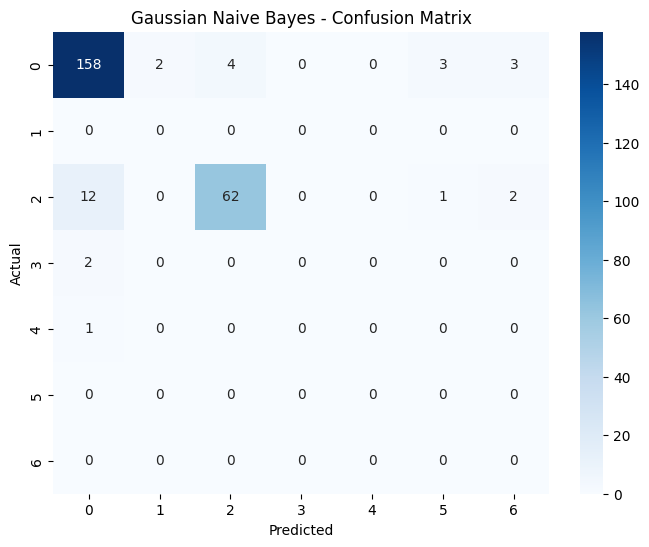

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       170
         0.0       0.00      0.00      0.00         0
           1       0.94      0.81      0.87        77
         1.0       0.00      0.00      0.00         2
       FALSE       0.00      0.00      0.00         1
          No       0.00      0.00      0.00         0
         Yes       0.00      0.00      0.00         0

    accuracy                           0.88       250
   macro avg       0.26      0.25      0.26       250
weighted avg       0.91      0.88      0.89       250



,Actual,Predicted
215,1,1
209,1,1
322,1,1
945,0,0
691,1,0
452,1,1
319,0,0
408,0,0
481,1,Yes
958,1,1


In [99]:
# Confusion Matrix and Classification Report

cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8,6))
sns.heatmap(cm_nb, annot = True, fmt = 'd', cmap = 'Blues')
plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report")
print(classification_report(y_test, y_pred_nb))

# Actual vs Predicted
comparison_nb = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_nb
})
comparison_nb.head(10)

In [100]:
# Store Results

results.append({
    "Model":"Gaussian Naive Bayes",
    "Accuracy":accuracy_nb,
    "Precision":precision_nb,
    "Recall":recall_nb,
    "F1 Score":f1_nb
})
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.932,0.920802,0.932,0.925939
1,Decision Tree,0.952,0.959810,0.952,0.955882
2,Random Forest,0.984,0.972368,0.984,0.978080
3,KNN,0.920,0.916421,0.920,0.912003
4,Support Vector Machine,0.960,0.949340,0.960,0.953990
5,Gaussian Naive Bayes,0.880,0.910374,0.880,0.893549


In [101]:
# Create Model Comparison Table

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.932,0.920802,0.932,0.925939
1,Decision Tree,0.952,0.959810,0.952,0.955882
2,Random Forest,0.984,0.972368,0.984,0.978080
3,KNN,0.920,0.916421,0.920,0.912003
4,Support Vector Machine,0.960,0.949340,0.960,0.953990
5,Gaussian Naive Bayes,0.880,0.910374,0.880,0.893549


In [102]:
# Sort Models by Accuracy

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.984,0.972368,0.984,0.978080
1,Support Vector Machine,0.960,0.949340,0.960,0.953990
2,Decision Tree,0.952,0.959810,0.952,0.955882
3,Logistic Regression,0.932,0.920802,0.932,0.925939
4,KNN,0.920,0.916421,0.920,0.912003
5,Gaussian Naive Bayes,0.880,0.910374,0.880,0.893549


In [103]:
# Best Model

best_model = results_df.iloc[0]
print("Best Model")
print("-"*40)
print(best_model)

Best Model
----------------------------------------
Model        Random Forest
Accuracy             0.984
Precision         0.972368
Recall               0.984
F1 Score           0.97808
Name: 0, dtype: object


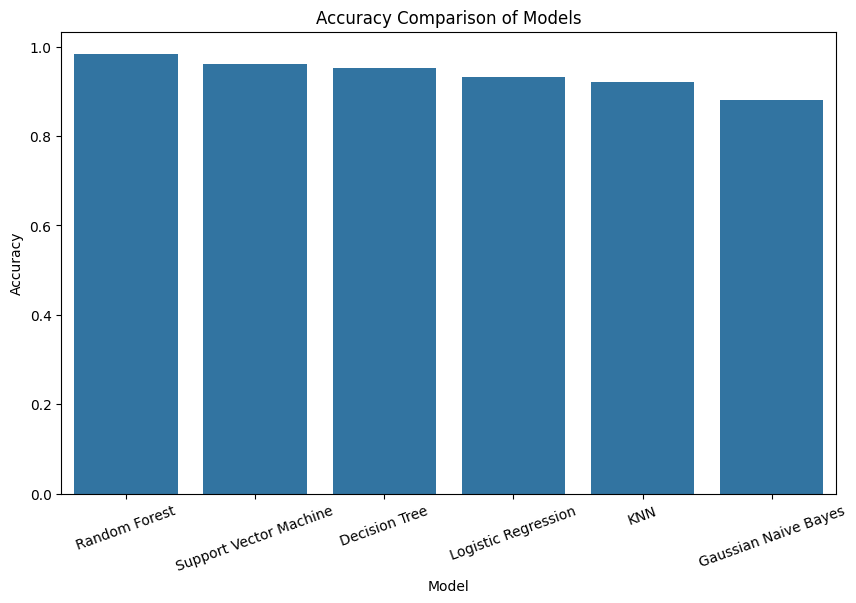

In [104]:
# Accuracy Comparison

plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of Models")
plt.xticks(rotation=20)
plt.show()

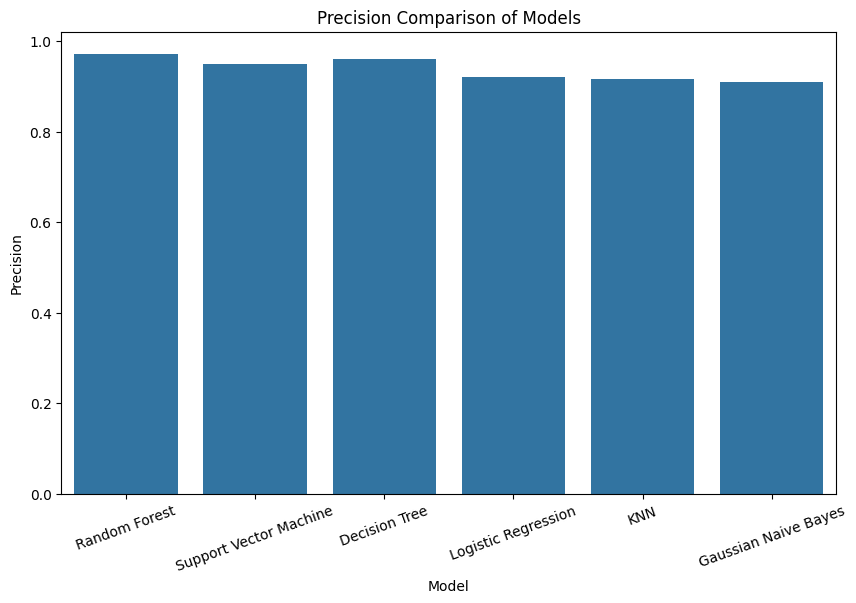

In [105]:
# Precision Comparison

plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df,
    x="Model",
    y="Precision"
)
plt.title("Precision Comparison of Models")
plt.xticks(rotation=20)
plt.show()

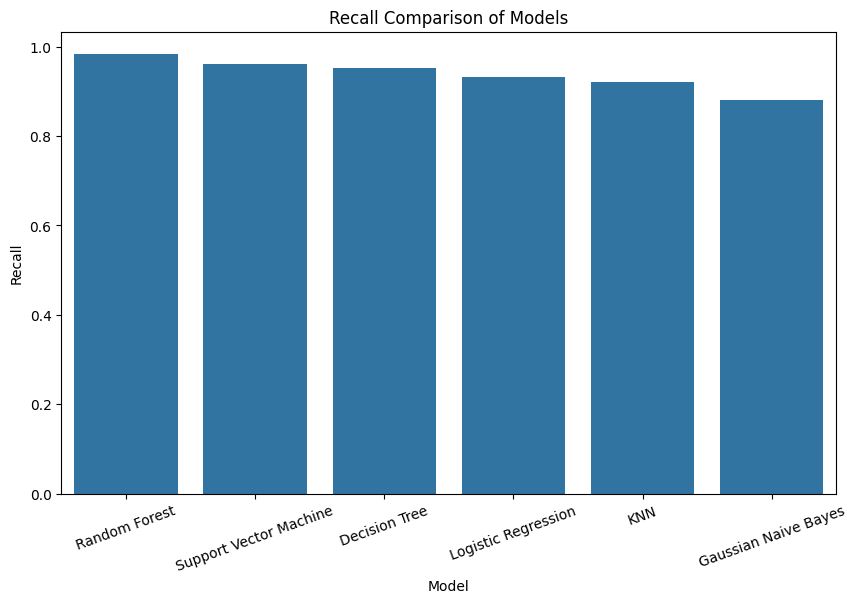

In [106]:
# Recall Comparison

plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df,
    x="Model",
    y="Recall"
)
plt.title("Recall Comparison of Models")
plt.xticks(rotation=20)
plt.show()

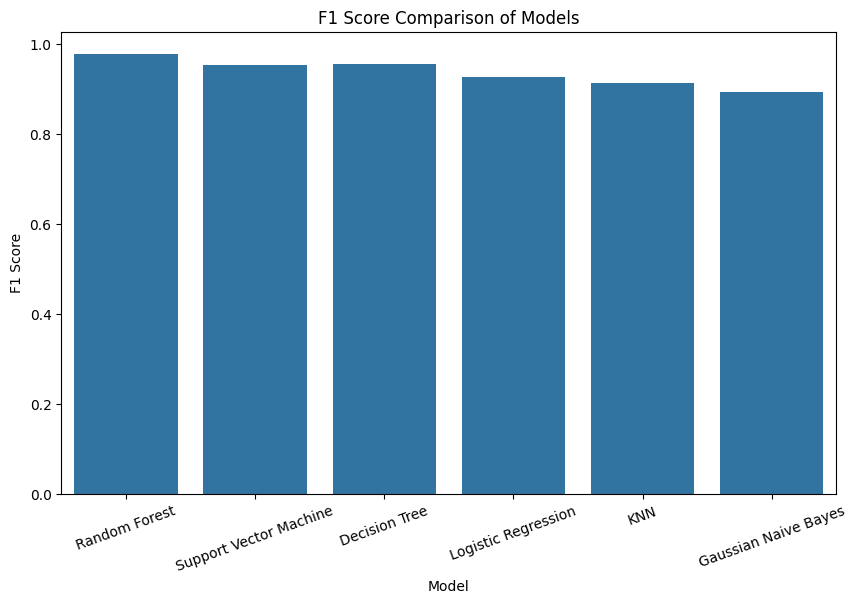

In [107]:
# F1 Score Comparison

plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score"
)
plt.title("F1 Score Comparison of Models")
plt.xticks(rotation=20)
plt.show()

In [108]:
#  Final Comparison Table
print(results_df)

                    Model  Accuracy  Precision  Recall  F1 Score
0           Random Forest     0.984   0.972368   0.984  0.978080
1  Support Vector Machine     0.960   0.949340   0.960  0.953990
2           Decision Tree     0.952   0.959810   0.952  0.955882
3     Logistic Regression     0.932   0.920802   0.932  0.925939
4                     KNN     0.920   0.916421   0.920  0.912003
5    Gaussian Naive Bayes     0.880   0.910374   0.880  0.893549


In [109]:
# =========================================================
# Select Best Model
# =========================================================

model_dict = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "KNN": knn,
    "Support Vector Machine": svm,
    "Gaussian Naive Bayes": naive_bayes
}
best_model_name = results_df.iloc[0]["Model"]
best_classifier = model_dict[best_model_name]
print("Best Model Selected :", best_model_name)

Best Model Selected : Random Forest


In [110]:
# Save Best Model

joblib.dump(best_classifier, "Best_Diabetes_Model.pkl")
print("Best Model Saved Successfully")

Best Model Saved Successfully


In [111]:
# Save Scaler

joblib.dump(scaler, "Scaler.pkl")
print("Scaler Saved Successfully")

Scaler Saved Successfully


In [112]:
# Load Saved Model

loaded_model = joblib.load("Best_Diabetes_Model.pkl")
loaded_scaler = joblib.load("Scaler.pkl")
print("Model Loaded Successfully")

Model Loaded Successfully


In [113]:
# Predict New Patient

sample_data = np.array([[
    2,          # Pregnancies
    120,        # Glucose
    70,         # BloodPressure
    20,         # SkinThickness
    85,         # Insulin
    28.5,       # BMI
    0.45,       # DiabetesPedigreeFunction
    35,         # Age
    180,        # Cholesterol
    138,        # SodiumLevel
    76,         # HeartRate
    32,         # VitaminD
    4           # ExerciseHrsPerWeek
]])
sample_scaled = loaded_scaler.transform(sample_data)
prediction = loaded_model.predict(sample_scaled)
print("Prediction :", prediction[0])

if prediction[0] == 1:
    print("Patient is Diabetic")
else:
    print("Patient is Non-Diabetic")

Prediction : 0
Patient is Non-Diabetic


In [114]:
# =========================================================
# Q15 : Project Conclusion
# =========================================================

print("="*40)
print("DIABETES PREDICTION PROJECT")
print("="*40)

print("""
1. Dataset loaded successfully.

2. Missing values and duplicate records were handled.

3. Invalid zero values were replaced appropriately.

4. Data preprocessing was completed using train-test split and feature scaling.

5. Six classification algorithms were trained:
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • K-Nearest Neighbors (KNN)
   • Support Vector Machine (SVM)
   • Gaussian Naive Bayes

6. Each model was evaluated using:
   • Accuracy
   • Precision
   • Recall
   • F1 Score
   • Confusion Matrix
   • Classification Report

7. The best-performing model was automatically selected based on accuracy.

8. The trained model was saved using Joblib.

9. The saved model was used to predict diabetes for a new patient.

10. This project demonstrates a complete end-to-end machine learning classification pipeline for diabetes prediction.
""")

DIABETES PREDICTION PROJECT

1. Dataset loaded successfully.

2. Missing values and duplicate records were handled.

3. Invalid zero values were replaced appropriately.

4. Data preprocessing was completed using train-test split and feature scaling.

5. Six classification algorithms were trained:
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • K-Nearest Neighbors (KNN)
   • Support Vector Machine (SVM)
   • Gaussian Naive Bayes

6. Each model was evaluated using:
   • Accuracy
   • Precision
   • Recall
   • F1 Score
   • Confusion Matrix
   • Classification Report

7. The best-performing model was automatically selected based on accuracy.

8. The trained model was saved using Joblib.

9. The saved model was used to predict diabetes for a new patient.

10. This project demonstrates a complete end-to-end machine learning classification pipeline for diabetes prediction.

